# SENTINEL · Notebook 3 · `demand/`

**What this notebook builds:** the **Demand Model** from slide 4:

$$D_z = M \times \sum_c \left(N_c \times w_c\right) \times (1 + U)$$

> *N = patients per triage colour · w = resource use per patient · M = disaster multiplier · U = buffer for unverified reports*

It turns the casualty reports from Notebook 2 into **how many beds, ICU beds, operations, blood units, ambulance trips and dialysis slots each zone needs**, and shows the **zone cards** from slide 3.

### How to use it
Run the grey boxes **one at a time, top to bottom**, and wait for each ✅.
Keep your screen on while it runs. If you see `NameError`, use **☰ → Runtime → Run all**.

## Step 1 · Load the tools and the scenario
Allow Google Drive access when the pop-up appears.

In [1]:
!pip install -q folium
import math, json, os, sys, importlib
import pandas as pd
import folium
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/SENTINEL"
DATA_DIR = f"{BASE}/data"
CODE_DIR = f"{BASE}/code/demand"
os.makedirs(CODE_DIR, exist_ok=True)

if not os.path.exists(f"{DATA_DIR}/scenario.json"):
    print("❌ scenario.json not found. Open Notebook 2 and run all steps including Step 13.")
else:
    with open(f"{DATA_DIR}/scenario.json") as f:
        S = json.load(f)
    casualties, hospitals, zones, events = S["casualties"], S["hospitals"], S["zones"], S["events"]
    print(f"✅ Step 1 done: {len(casualties)} casualties, {len(hospitals)} hospitals, {len(zones)} zones loaded")

Mounted at /content/drive
✅ Step 1 done: 160 casualties, 12 hospitals, 5 zones loaded


## Step 2 · What each symbol means

| Symbol | Meaning | Example |
|---|---|---|
| $N_c$ | patients **known** in the zone, per triage colour $c$ | 6 Red, 9 Yellow, 20 Green |
| $w_c$ | how much of a resource **one** patient of colour $c$ uses | a Red patient uses 1 bed, 3 blood units |
| $M$ | **disaster multiplier**: some disasters need more of a resource | a building collapse needs 1.5× more operations; 21.6% of crush patients need dialysis |
| $U$ | **buffer** for people not yet reported | at minute 0, U ≈ 2.7, meaning "expect about 3.7× the people you know about" |

**How U works.** Research in our deck shows first counts run 3–4× too low. We model the share of casualties reported so far as:

$$\text{coverage}(t) = 1 - (1 - c_0)\, e^{-t/T} \qquad U = \frac{1}{\text{coverage}(t)} - 1 + \kappa\,(1 - \text{confidence})$$

- $c_0 = 0.27$: about a quarter of people are known at first (3–4× undercount)
- $T = 40$ min: how fast reports catch up *(assumed)*
- $\kappa = 0.2$: extra buffer when reports come from less reliable sources (e.g. phone calls)

So **U is large at first and shrinks as reports arrive and are verified**. A new incident (the building collapse) starts its own clock.

## Step 3 · Save the Demand Model as a file
This box writes the model into **Google Drive → SENTINEL → code → demand → demand_model.py**.
The optimiser (Notebook 4) and the final website will reuse this exact file.

In [2]:
%%writefile /content/drive/MyDrive/SENTINEL/code/demand/demand_model.py
# SENTINEL demand/ · Demand Model:  D_z = M × Σ_c (N_c × w_c) × (1 + U)
import math

TRIAGE = ["RED", "YELLOW", "GREEN", "GREY"]
RESOURCES = ["beds", "icu", "ot", "blood_units", "als_trips", "bls_trips", "dialysis"]

# w_c · resource use per patient of colour c (planning weights, assumed)
W = {
    "beds":        {"RED": 1.0, "YELLOW": 1.0, "GREEN": 0.0, "GREY": 0.0},
    "icu":         {"RED": 0.5, "YELLOW": 0.0, "GREEN": 0.0, "GREY": 0.0},
    "ot":          {"RED": 1.0, "YELLOW": 0.2, "GREEN": 0.0, "GREY": 0.0},
    "blood_units": {"RED": 3.0, "YELLOW": 0.5, "GREEN": 0.0, "GREY": 0.0},
    "als_trips":   {"RED": 1.0, "YELLOW": 0.0, "GREEN": 0.0, "GREY": 0.0},
    "bls_trips":   {"RED": 0.0, "YELLOW": 0.5, "GREEN": 0.1, "GREY": 0.0},
    "dialysis":    {"RED": 1.0, "YELLOW": 0.0, "GREEN": 0.0, "GREY": 0.0},
}

# M · disaster-type multiplier per resource
# collapse dialysis 0.216 = share of crush patients needing dialysis (Kahramanmaraş 2023 study); others assumed
M = {
    "flood":    {"beds": 1.0, "icu": 1.0, "ot": 0.8, "blood_units": 1.0, "als_trips": 1.0, "bls_trips": 1.0, "dialysis": 0.05},
    "collapse": {"beds": 1.0, "icu": 1.2, "ot": 1.5, "blood_units": 1.3, "als_trips": 1.0, "bls_trips": 1.0, "dialysis": 0.216},
}

# U · buffer for unverified / unreported casualties
C0 = 0.27      # share of casualties known at the start (first counts run 3-4x low)
T_COVER = 40   # minutes for reports to catch up (assumed)
KAPPA = 0.2    # extra buffer for low-confidence sources (assumed)

def coverage(minutes_since_start):
    return 1 - (1 - C0) * math.exp(-max(minutes_since_start, 0) / T_COVER)

def uncertainty_buffer(minutes_since_start, avg_confidence=1.0):
    return (1 / coverage(minutes_since_start) - 1) + KAPPA * (1 - avg_confidence)

def triage_now(c, minute, treated=frozenset()):
    # Yellow patients deteriorate to Red if not treated in time
    if (c["triage"] == "YELLOW" and c.get("deteriorate_at") is not None
            and minute >= c["deteriorate_at"] and c["id"] not in treated):
        return "RED"
    return c["triage"]

def known_patients(casualties, minute, zone=None):
    return [c for c in casualties
            if c["injured_at"] <= minute and c["reported_at"] <= minute
            and (zone is None or c["zone"] == zone)]

def incident_starts(events):
    starts = {"flood": 0}
    for e in events:
        if e["type"] == "collapse":
            starts["collapse"] = e["t"]
    return starts

def zone_demand(casualties, minute, zone, starts, treated=frozenset(), with_buffer=True):
    # Returns D_z for every resource, plus the N_c counts and U used, per cause
    D = {r: 0.0 for r in RESOURCES}
    detail = {}
    for cause, start in starts.items():
        if minute < start:
            continue
        people = [c for c in known_patients(casualties, minute, zone) if c["cause"] == cause]
        if not people:
            continue
        N = {col: 0 for col in TRIAGE}
        for c in people:
            N[triage_now(c, minute, treated)] += 1
        avg_conf = sum(c["confidence"] for c in people) / len(people)
        U = uncertainty_buffer(minute - start, avg_conf) if with_buffer else 0.0
        for r in RESOURCES:
            D[r] += M[cause][r] * sum(N[col] * W[r][col] for col in TRIAGE) * (1 + U)
        detail[cause] = {"N": N, "U": round(U, 2), "confidence": round(avg_conf, 2)}
    return D, detail

def total_demand(casualties, minute, zones, starts, treated=frozenset(), with_buffer=True):
    total = {r: 0.0 for r in RESOURCES}
    for z in zones:
        D, _ = zone_demand(casualties, minute, z["id"], starts, treated, with_buffer)
        for r in RESOURCES:
            total[r] += D[r]
    return total

def unreported_reserve(casualties, minute, zones, starts, treated=frozenset()):
    # Expected demand from people not yet reported = buffered − known.
    # The optimiser holds this much capacity back ("capacity minus reserve").
    a = total_demand(casualties, minute, zones, starts, treated, True)
    b = total_demand(casualties, minute, zones, starts, treated, False)
    return {r: max(a[r] - b[r], 0.0) for r in RESOURCES}

Writing /content/drive/MyDrive/SENTINEL/code/demand/demand_model.py


## Step 4 · Use the model: a worked example
We calculate **beds needed in Zone Z1 at minute 45**, step by step, exactly as the formula says.

In [3]:
sys.path.insert(0, CODE_DIR)
import demand_model as dm
importlib.reload(dm)

starts = dm.incident_starts(events)
MINUTE, ZONE = 45, "Z1"
D, detail = dm.zone_demand(casualties, MINUTE, ZONE, starts)
d = detail["flood"]
N = d["N"]
weighted = sum(N[c] * dm.W["beds"][c] for c in dm.TRIAGE)

print(f"Zone {ZONE}, minute {MINUTE}, resource = beds\n")
print(f"  N (known patients)   : Red {N['RED']}, Yellow {N['YELLOW']}, Green {N['GREEN']}, Grey {N['GREY']}")
print(f"  w (beds per patient) : Red 1, Yellow 1, Green 0, Grey 0")
print(f"  Σ N×w                : {weighted:.0f}")
print(f"  M (flood, beds)      : {dm.M['flood']['beds']}")
print(f"  U (buffer)           : {d['U']}  (coverage so far {dm.coverage(MINUTE):.0%}, report confidence {d['confidence']})")
print(f"  D = M × Σ(N×w) × (1+U) = {dm.M['flood']['beds']} × {weighted:.0f} × {1 + d['U']:.2f} = {D['beds']:.1f} beds")
print("\n✅ Step 4 done: the Demand Model works")

Zone Z1, minute 45, resource = beds

  N (known patients)   : Red 6, Yellow 10, Green 26, Grey 4
  w (beds per patient) : Red 1, Yellow 1, Green 0, Grey 0
  Σ N×w                : 16
  M (flood, beds)      : 1.0
  U (buffer)           : 0.35  (coverage so far 76%, report confidence 0.82)
  D = M × Σ(N×w) × (1+U) = 1.0 × 16 × 1.35 = 21.5 beds

✅ Step 4 done: the Demand Model works


## Step 5 · Zone cards (slide 3)
Each zone card shows **START/SALT triage counts, access status, timestamp and source confidence**, plus the demand.
Change `CARD_MINUTE` to 0, 45 or 90 and run this box again to watch the picture change.

In [4]:
CARD_MINUTE = 45

FLOOD_CENTER = (zones[0]["lat"], zones[0]["lon"])   # Zone Z1 sits on the flood centre

def metres(a, b):
    dy = (a[0] - b[0]) * 111320
    dx = (a[1] - b[1]) * 111320 * math.cos(math.radians(a[0]))
    return math.hypot(dx, dy)

def access_status(z, minute):
    status = "Open"
    floods = [e for e in events if e["type"] == "flood" and e["t"] <= minute]
    if floods and metres((z["lat"], z["lon"]), FLOOD_CENTER) <= floods[-1]["radius_m"]:
        status = f"Flooded ({floods[-1]['factor']:.0f}x slower)"
    if any(e["type"] == "collapse" and e["t"] <= minute and e["zone"] == z["id"] for e in events):
        status += " + collapse"
    return status

known_rows, demand_rows = [], []
for z in zones:
    D, detail = dm.zone_demand(casualties, CARD_MINUTE, z["id"], starts)
    N = {c: sum(dt["N"][c] for dt in detail.values()) for c in dm.TRIAGE}
    seen = dm.known_patients(casualties, CARD_MINUTE, z["id"])
    conf = round(sum(c["confidence"] for c in seen) / len(seen), 2) if seen else "-"
    known_rows.append({"zone": z["id"], "Red": N["RED"], "Yellow": N["YELLOW"], "Green": N["GREEN"],
                       "Grey": N["GREY"], "confidence": conf,
                       "access": access_status(z, CARD_MINUTE)})
    demand_rows.append({"zone": z["id"], "beds": round(D["beds"]), "ICU": round(D["icu"]),
                        "ops": round(D["ot"]), "blood": round(D["blood_units"]),
                        "ALS trips": round(D["als_trips"]), "dialysis": round(D["dialysis"], 1)})

print(f"ZONE CARDS · minute {CARD_MINUTE} · KNOWN PATIENTS")
print(pd.DataFrame(known_rows).to_string(index=False))
print(f"\nZONE CARDS · minute {CARD_MINUTE} · DEMAND WITH BUFFER U")
print(pd.DataFrame(demand_rows).to_string(index=False))
print("\n✅ Step 5 done: zone cards ready")

ZONE CARDS · minute 45 · KNOWN PATIENTS
zone  Red  Yellow  Green  Grey  confidence              access
  Z1    6      10     26     4        0.82 Flooded (3x slower)
  Z2    5       6      5     0        0.80                Open
  Z3    3       2     12     1        0.80                Open
  Z4    3       5      8     1        0.84                Open
  Z5    1       6     11     0        0.80                Open

ZONE CARDS · minute 45 · DEMAND WITH BUFFER U
zone  beds  ICU  ops  blood  ALS trips  dialysis
  Z1    22    4    9     31          8       0.4
  Z2    15    3    7     24          7       0.3
  Z3     7    2    4     14          4       0.2
  Z4    11    2    4     15          4       0.2
  Z5     9    1    2      8          1       0.1

✅ Step 5 done: zone cards ready


## Step 6 · Does the buffer U actually help?
We compare three answers to *"how many beds are needed?"* over 2 hours:
- **True need**: counts everyone, even people not yet reported (only the simulation knows this)
- **Naive count**: only people already reported (what most dashboards show)
- **SENTINEL**: our formula with buffer U

The closer SENTINEL's line is to the true line, the better the model.

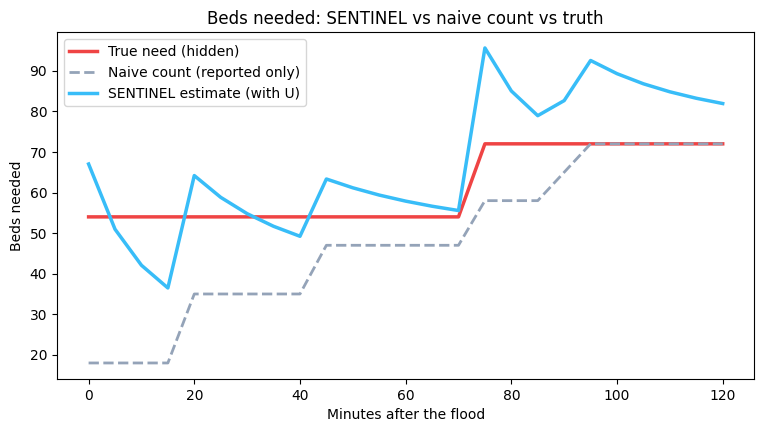

Average error, naive count : 13.2 beds
Average error, SENTINEL    : 9.6 beds
→ SENTINEL's estimate is 28% closer to the truth
✅ Step 6 done


In [5]:
minutes = list(range(0, S["horizon_min"] + 1, 5))
true_beds, naive_beds, sentinel_beds = [], [], []
for t in minutes:
    exists = [c for c in casualties if c["injured_at"] <= t]
    true_beds.append(sum(dm.W["beds"][dm.triage_now(c, t)] for c in exists))
    naive_beds.append(dm.total_demand(casualties, t, zones, starts, with_buffer=False)["beds"])
    sentinel_beds.append(dm.total_demand(casualties, t, zones, starts, with_buffer=True)["beds"])

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(minutes, true_beds, color="#EF4444", linewidth=2.5, label="True need (hidden)")
ax.plot(minutes, naive_beds, color="#94A3B8", linewidth=2, linestyle="--", label="Naive count (reported only)")
ax.plot(minutes, sentinel_beds, color="#38BDF8", linewidth=2.5, label="SENTINEL estimate (with U)")
ax.set_xlabel("Minutes after the flood")
ax.set_ylabel("Beds needed")
ax.set_title("Beds needed: SENTINEL vs naive count vs truth")
ax.legend()
plt.show()

err_naive = sum(abs(a - b) for a, b in zip(naive_beds, true_beds)) / len(minutes)
err_sent = sum(abs(a - b) for a, b in zip(sentinel_beds, true_beds)) / len(minutes)
print(f"Average error, naive count : {err_naive:.1f} beds")
print(f"Average error, SENTINEL    : {err_sent:.1f} beds")
print(f"→ SENTINEL's estimate is {100 * (1 - err_sent / err_naive):.0f}% closer to the truth")
print("✅ Step 6 done")

## Step 7 · Demand vs capacity
Capacity changes too: at minute 50 a hospital loses power and at minute 80 another runs out of O+ blood.
Where the blue bar is taller than the green bar, there is a **shortage**, and that is exactly why the optimiser in Notebook 4 must decide carefully who gets what.

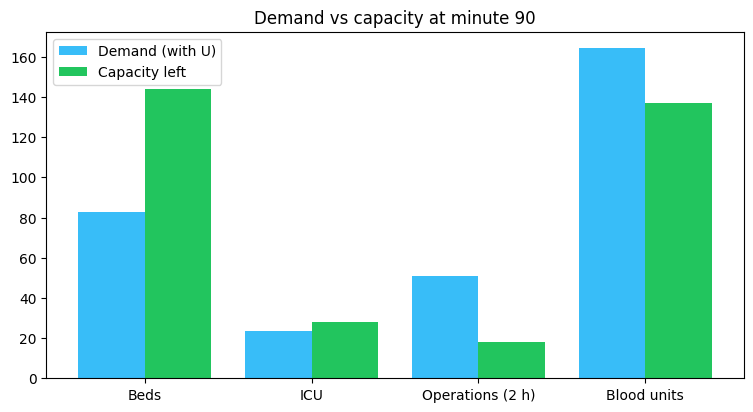

  beds         need     83 | have  144 | ok
  icu          need     23 | have   28 | ok
  ot (2 h)     need     51 | have   18 | SHORTAGE
  blood_units  need    164 | have  137 | SHORTAGE
✅ Step 7 done


In [6]:
def capacity_at(minute):
    cap = {"beds": 0, "icu": 0, "ot (2 h)": 0, "blood_units": 0}
    down = {e["hospital"] for e in events if e["type"] == "hospital_down" and e["t"] <= minute}
    no_blood = {(e["hospital"], e["group"]) for e in events if e["type"] == "blood_shortage" and e["t"] <= minute}
    for h in hospitals:
        failed = h["id"] in down
        cap["beds"] += h["beds"] // 2 if failed else h["beds"]
        cap["icu"] += 0 if failed else h["icu"]
        cap["ot (2 h)"] += h["ot_per_hr"] * 2
        cap["blood_units"] += sum(units for g, units in h["blood"].items() if (h["id"], g) not in no_blood)
    return cap

COMPARE_AT = 90
need = dm.total_demand(casualties, COMPARE_AT, zones, starts)
have = capacity_at(COMPARE_AT)
labels = ["beds", "icu", "ot (2 h)", "blood_units"]
need_vals = [need["beds"], need["icu"], need["ot"], need["blood_units"]]
have_vals = [have[k] for k in labels]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(labels))
ax.bar([i - 0.2 for i in x], need_vals, width=0.4, color="#38BDF8", label="Demand (with U)")
ax.bar([i + 0.2 for i in x], have_vals, width=0.4, color="#22C55E", label="Capacity left")
ax.set_xticks(list(x))
ax.set_xticklabels(["Beds", "ICU", "Operations (2 h)", "Blood units"])
ax.set_title(f"Demand vs capacity at minute {COMPARE_AT}")
ax.legend()
plt.show()
for lab, n, h in zip(labels, need_vals, have_vals):
    flag = "SHORTAGE" if n > h else "ok"
    print(f"  {lab:<12} need {n:6.0f} | have {h:4.0f} | {flag}")
print("✅ Step 7 done")

## Step 8 · Save the demand timeline
Saves zone-by-zone demand every 5 minutes to **demand_timeline.json**, so the website can replay it.

In [7]:
timeline = []
for t in minutes:
    for z in zones:
        D, detail = dm.zone_demand(casualties, t, z["id"], starts)
        timeline.append({"minute": t, "zone": z["id"], **{r: round(v, 2) for r, v in D.items()},
                         "U": {k: v["U"] for k, v in detail.items()}})
with open(f"{DATA_DIR}/demand_timeline.json", "w") as f:
    json.dump(timeline, f, indent=1)
print(f"✅ Step 8 done: {len(timeline)} rows saved to demand_timeline.json")
print("🎉 Notebook 3 complete. Send Claude screenshots of Steps 4, 5, 6 and 7.")

✅ Step 8 done: 125 rows saved to demand_timeline.json
🎉 Notebook 3 complete. Send Claude screenshots of Steps 4, 5, 6 and 7.


## What you just built (say this to a judge)
> *"Our demand model turns triage counts into resource needs per zone: D = M × Σ(N × w) × (1 + U). N is the number of known patients per START/SALT colour, w is how much of each resource one patient uses, M adjusts for the disaster type (for example, 21.6% of crush patients need dialysis), and U is a buffer for people not yet reported. U is large at first, because first counts run 3–4× low, and shrinks as reports are verified. In our simulation, this estimate stays much closer to the true need than a simple count of reports."*

| Slide says | Where |
|---|---|
| D = M × Σ(N × w) × (1 + U) | Step 3 (`zone_demand`), worked example in Step 4 |
| Buffer U for unverified reports | Steps 2–3 (`uncertainty_buffer`) and Step 6 (proof it helps) |
| Zone cards: triage counts, access, timestamp, source confidence | Step 5 |
| Beds, ICU, OT, blood, ambulances per zone | Step 5 |
| Capacity minus reserve (used by the optimiser) | Step 3 (`unreported_reserve`) |